In [2]:
import numpy as np 
# import sklearn as sk
import matplotlib.pyplot as plt
import pandas as pd
from helpreg import *

In [3]:
np.set_printoptions(precision=3, formatter={'float_kind': '{:0.3f}'.format})

In [4]:
x1 = np.array([-1, -0.743, -0.486, -0.229, 0.028, 0.285, 0.542, 0.799, 1.056, 1.313])
x2 = np.array([-1.979, -1.472, -0.974, -0.465, 0.061, 0.565, 1.093, 1.587, 2.114, 2.628])
y = np.array([-0.022, -0.485, -0.582, -0.386, 0.212, 0.996, 1.758, 2.795, 4.383, 5.874])
betta = [-2, 2, 1]

In [5]:
F = np.round(np.array([
    x1,
    x2,
    x1 * x2,
]), 4)

In [6]:
F.T # Матрица регрессоров

array([[-1.000, -1.979, 1.979],
       [-0.743, -1.472, 1.094],
       [-0.486, -0.974, 0.473],
       [-0.229, -0.465, 0.106],
       [0.028, 0.061, 0.002],
       [0.285, 0.565, 0.161],
       [0.542, 1.093, 0.592],
       [0.799, 1.587, 1.268],
       [1.056, 2.114, 2.232],
       [1.313, 2.628, 3.451]])

In [7]:
print("F = ", pmatrix(F.T,3))
print("y = ", pmatrix(y, 4, T=True))

F =  \begin{pmatrix}
  -1.000 & -1.979 & 1.979\\
  -0.743 & -1.472 & 1.094\\
  -0.486 & -0.974 & 0.473\\
  -0.229 & -0.465 & 0.106\\
  0.028 & 0.061 & 0.002\\
  0.285 & 0.565 & 0.161\\
  0.542 & 1.093 & 0.592\\
  0.799 & 1.587 & 1.268\\
  1.056 & 2.114 & 2.232\\
  1.313 & 2.628 & 3.451\\
\end{pmatrix}
y =  \begin{pmatrix}
  -0.022\\ -0.485\\ -0.582\\ -0.386\\ 0.212\\ 0.996\\ 1.758\\ 2.795\\ 4.383\\ 5.874
\end{pmatrix}


In [8]:
vrn = F @ y 
print(pmatrix(vrn, T = True)) # вектор системы нормальных уравнений
vrn

\begin{pmatrix}
  16.570\\ 33.139\\ 33.909
\end{pmatrix}


array([16.570, 33.139, 33.909])

In [9]:
G = F @ F.T
print(pmatrix(G)) # информационная матрица

\begin{pmatrix}
  5.694 & 11.359 & 5.222\\
  11.359 & 22.660 & 10.501\\
  5.222 & 10.501 & 24.223\\
\end{pmatrix}


In [10]:
C = np.linalg.inv(G)
print(pmatrix(C)) # матрица дисперсий-ковариаций

\begin{pmatrix}
  9083.075 & -4562.202 & 19.670\\
  -4562.202 & 2291.535 & -9.904\\
  19.670 & -9.904 & 0.094\\
\end{pmatrix}


In [11]:
b = C @ vrn
print(pmatrix(b, T=False)) # вектор оценок регрессионых
# коэффициентов без учета заданных линейных ограничений

\begin{pmatrix}
  -10.015 & 6.049 & 0.937\\
\end{pmatrix}


In [12]:
def lin_model(b):
    return np.round(b[0]* x1 + b[1] * x2 + b[2] * x1*x2, 3)

In [14]:
b, betta

(array([-10.015, 6.049, 0.937]), [-2, 2, 1])

Сравнивая полученные оценки регрессионных коэффициентов с
известными истинными значениями, получаем

In [55]:
np.abs(b-betta) / np.abs(betta) * 100 # 

array([400.771, 202.440, 6.329])

Суммарная квадратичная ошибка

In [60]:
np.sum((b - betta)**2)

np.float64(80.6436446736362)

Вычислим $\text{cond}(F^T F)$

In [62]:
np.linalg.cond(F @ F.T)

np.float64(434473.45329492347)

In [64]:
np.linalg.norm(F @ F.T) * np.linalg.norm(np.linalg.inv(F@F.T))

np.float64(464241.8046934782)

In [65]:
f_mean= F.mean(axis=1)
f_mean = np.append(f_mean, y.mean())
l = np.round([np.sum((F[i] - f_mean[i])**2)**0.5 for i in range(3)], 3)
l = np.append(l, np.sum((y - y.mean())**2)**0.5)

print(l)
print(f_mean)

[2.334 4.654 3.365 6.725]
[0.157 0.316 1.136 1.454]


In [16]:
print(l)

[2.334 4.654 3.365 6.725]


In [17]:
df = pd.DataFrame({'k': [x for x in range(1, 11)],
                    '$f_{k1}$': F[0],
                    '$f_{k2}$': F[1],
                    '$f_{k3}$': F[2],
                    '$y$': y,
                    '$\\xi_{k1}': np.round((F[0] - f_mean[0]) / l[0], 3),
                    '$\\xi_{k2}': np.round((F[1] - f_mean[1]) / l[1], 3),
                    '$\\xi_{k3}': np.round((F[2] - f_mean[2]) / l[2], 3),
                    '$\\varsigma_{k1}': np.round((y - f_mean[3]) / l[3], 3)
                   })

print(df.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \\hline\n"))

\begin{tabular}{rrrrrrrrr}
\toprule
k & $f_{k1}$ & $f_{k2}$ & $f_{k3}$ & $y$ & $\xi_{k1} & $\xi_{k2} & $\xi_{k3} & $\varsigma_{k1} \\ \hline
\midrule
1 & -1.000 & -1.979 & 1.979 & -0.022 & -0.496 & -0.493 & 0.251 & -0.220 \\ \hline
2 & -0.743 & -1.472 & 1.094 & -0.485 & -0.385 & -0.384 & -0.013 & -0.288 \\ \hline
3 & -0.486 & -0.974 & 0.473 & -0.582 & -0.275 & -0.277 & -0.197 & -0.303 \\ \hline
4 & -0.229 & -0.465 & 0.106 & -0.386 & -0.165 & -0.168 & -0.306 & -0.274 \\ \hline
5 & 0.028 & 0.061 & 0.002 & 0.212 & -0.055 & -0.055 & -0.337 & -0.185 \\ \hline
6 & 0.285 & 0.565 & 0.161 & 0.996 & 0.055 & 0.054 & -0.290 & -0.068 \\ \hline
7 & 0.542 & 1.093 & 0.592 & 1.758 & 0.165 & 0.167 & -0.162 & 0.045 \\ \hline
8 & 0.799 & 1.587 & 1.268 & 2.795 & 0.275 & 0.273 & 0.039 & 0.199 \\ \hline
9 & 1.056 & 2.114 & 2.232 & 4.383 & 0.385 & 0.386 & 0.326 & 0.435 \\ \hline
10 & 1.313 & 2.628 & 3.451 & 5.874 & 0.496 & 0.497 & 0.688 & 0.657 \\ \hline
\bottomrule
\end{tabular}



In [18]:
F_e = df[df.columns[5:8]]
R = F_e.T @ F_e # Матрица кореляций регрессии

In [19]:
F_e

,$\xi_{k1},$\xi_{k2},$\xi_{k3}
0,-0.496,-0.493,0.251
1,-0.385,-0.384,-0.013
2,-0.275,-0.277,-0.197
3,-0.165,-0.168,-0.306
4,-0.055,-0.055,-0.337
5,0.055,0.054,-0.290
6,0.165,0.167,-0.162
7,0.275,0.273,0.039
8,0.385,0.386,0.326
9,0.496,0.497,0.688


In [69]:
print("Матрица корелляционная матрица R", pmatrix(R.values))
print("detR = ", np.linalg.det(R))

Матрица корелляционная матрица R \begin{pmatrix}
  1.000 & 1.000 & 0.439\\
  1.000 & 1.000 & 0.441\\
  0.439 & 0.441 & 1.001\\
\end{pmatrix}
detR =  1.8140085711486417e-05


In [68]:
R.values

array([[1.000, 1.000, 0.439],
       [1.000, 1.000, 0.441],
       [0.439, 0.441, 1.001]])

выборе диапазона изменения параметра регуляризации в методе
гребневой регрессии

In [21]:
ride_bridge = pd.DataFrame({'k': [x for x in range(1, 11)],
               '$y_k$': y, 
                '$ \\hat{y_k} $': lin_model(b),
                '$(y-y_k)^2 $': (y-lin_model(b))**2 })

In [22]:
def s_oct(y, y_pred, n):
    return np.round(np.sum((y-y_pred)**2) / (len(y) - n), 3)
    

In [ ]:
ride_bridge

,k,$y_k$,$ \hat{y_k} $,$(y-y_k)^2 $
0,1,-0.022,-0.101,0.006241
1,2,-0.485,-0.438,0.002209
2,3,-0.582,-0.581,0.000001
3,4,-0.386,-0.419,0.001089
4,5,0.212,0.090,0.014884
5,6,0.996,0.714,0.079524
6,7,1.758,1.738,0.000400
7,8,2.795,2.785,0.000100
8,9,4.383,4.302,0.006561
9,10,5.874,5.978,0.010816


In [ ]:
y, y_pred = ride_bridge.iloc[:, 1], ride_bridge.iloc[:, 2]
n = 3
s = s_oct(y, y_pred, n)
print("$s_{\\text{ост}}^2=$", s)

$s_{\text{ост}}^2=$ 0.017


In [25]:
alpha = n * s**2 / np.sum(np.array(b)**2)
print(np.round(alpha, 6))

6e-06


In [39]:
h = alpha * 3 / 100
alpha_range = [round(float(h*i), 6) for i in range(0, 100)]
for i in alpha_range:
    print("{:.6f}".format(i), end=' ')

0.000000 0.000000 0.000000 0.000001 0.000001 0.000001 0.000001 0.000001 0.000002 0.000002 0.000002 0.000002 0.000002 0.000002 0.000003 0.000003 0.000003 0.000003 0.000003 0.000004 0.000004 0.000004 0.000004 0.000004 0.000005 0.000005 0.000005 0.000005 0.000005 0.000005 0.000006 0.000006 0.000006 0.000006 0.000006 0.000007 0.000007 0.000007 0.000007 0.000007 0.000008 0.000008 0.000008 0.000008 0.000008 0.000008 0.000009 0.000009 0.000009 0.000009 0.000009 0.000010 0.000010 0.000010 0.000010 0.000010 0.000011 0.000011 0.000011 0.000011 0.000011 0.000012 0.000012 0.000012 0.000012 0.000012 0.000012 0.000013 0.000013 0.000013 0.000013 0.000013 0.000014 0.000014 0.000014 0.000014 0.000014 0.000015 0.000015 0.000015 0.000015 0.000015 0.000015 0.000016 0.000016 0.000016 0.000016 0.000016 0.000017 0.000017 0.000017 0.000017 0.000017 0.000018 0.000018 0.000018 0.000018 0.000018 0.000019 0.000019 

In [27]:
(np.linalg.inv(G + alpha_range[0] * np.eye(3, 3)) @ vrn)

array([-10.015, 6.049, 0.937])

In [40]:
df = pd.DataFrame(
    [np.linalg.inv(G + alpha * np.eye(3, 3)) @ vrn for alpha in alpha_range],
    columns=['b1', 'b2', 'b3'],
    index=alpha_range
)
df.index.name = 'alpha'

In [41]:
df.T

alpha,0.000000,0.000000,0.000000,0.000001,0.000001,0.000001,0.000001,0.000001,0.000002,0.000002,...,0.000017,0.000017,0.000017,0.000018,0.000018,0.000018,0.000018,0.000018,0.000019,0.000019
b1,-10.015411,-10.015411,-10.015411,-9.898196,-9.898196,-9.898196,-9.898196,-9.898196,-9.783589,-9.783589,...,-8.326646,-8.326646,-8.326646,-8.244189,-8.244189,-8.244189,-8.244189,-8.244189,-8.163275,-8.163275
b2,6.048805,6.048805,6.048805,5.989931,5.989931,5.989931,5.989931,5.989931,5.932366,5.932366,...,5.200576,5.200576,5.200576,5.159160,5.159160,5.159160,5.159160,5.159160,5.118518,5.118518
b3,0.936712,0.936712,0.936712,0.936966,0.936966,0.936966,0.936966,0.936966,0.937214,0.937214,...,0.940370,0.940370,0.940370,0.940549,0.940549,0.940549,0.940549,0.940549,0.940724,0.940724


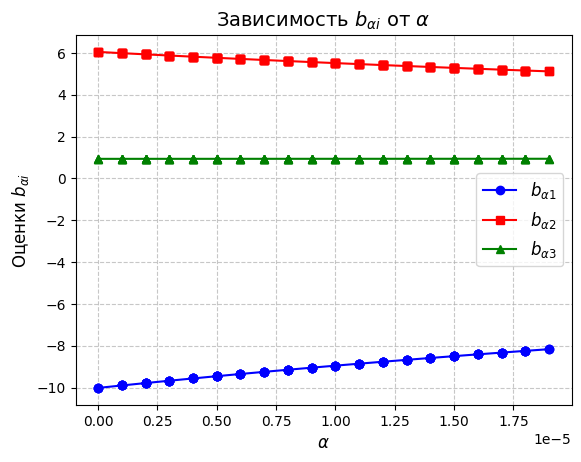

In [42]:
plt.plot(df.index, df['b1'], label='$b_{\\alpha 1}$', color='blue', marker='o')
plt.plot(df.index, df['b2'], label='$b_{\\alpha 2}$', color='red', marker='s')
plt.plot(df.index, df['b3'], label='$b_{\\alpha 3}$', color='green', marker='^')

# Настройки графика
plt.xlabel('$\\alpha$', fontsize=12)
plt.ylabel('Оценки $b_{\\alpha i}$', fontsize=12)
plt.title('Зависимость $b_{\\alpha i}$ от $\\alpha$', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

In [43]:
df['Q'] = (df - betta).pow(2).sum(axis=1)
df['lnQ'] = np.log(df['Q'])

In [32]:
df.T

alpha,0.000000,0.000001,0.000003,0.000004,0.000006,0.000007,0.000009,0.000010,0.000012,0.000013,0.000015,0.000016,0.000017
b1,-10.015411,-9.898196,-9.671502,-9.561855,-9.349565,-9.246775,-9.047558,-8.951002,-8.763687,-8.672815,-8.496367,-8.410690,-8.326646
b2,6.048805,5.989931,5.876067,5.820994,5.714365,5.662736,5.562674,5.514176,5.420092,5.374449,5.285823,5.242789,5.200576
b3,0.936712,0.936966,0.937457,0.937694,0.938154,0.938377,0.938808,0.939018,0.939423,0.939620,0.940002,0.940188,0.940370
Q,80.643645,78.305025,73.879755,71.785520,67.816434,65.935174,62.364467,60.669579,57.448169,55.917005,53.003012,51.616202,50.273692
lnQ,4.390040,4.360612,4.302439,4.273683,4.216805,4.188672,4.132996,4.105442,4.050883,4.023869,3.970349,3.943836,3.917482


<Axes: xlabel='alpha'>

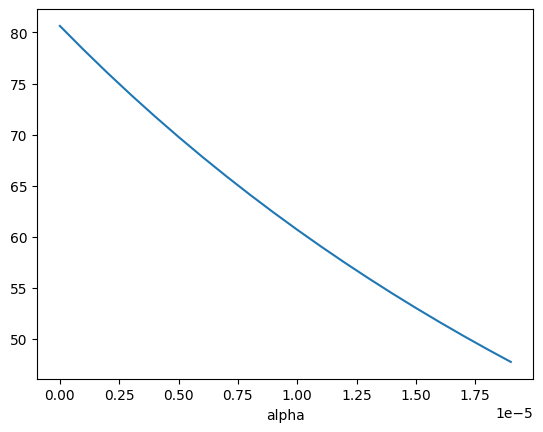

In [44]:
df['Q'].plot()

<Axes: xlabel='alpha'>

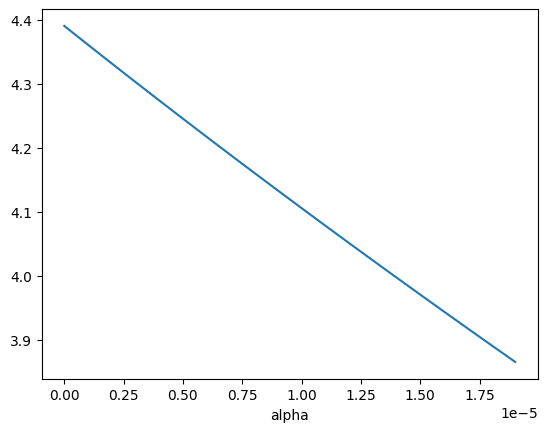

In [45]:
df['lnQ'].plot()